<a href="https://colab.research.google.com/github/AI-is-out-there/2026-REA-Diploma-Practical-Part/blob/main/Telemed-conf-AI-assistant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#import

In [2]:
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.7 MB/s eta 0:00:00


In [3]:
!pip install langchain-mistralai langchain-core langchain-community -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [10]:


# Импорты
import json
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict, Any
from langchain_mistralai import ChatMistralAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_classic.agents import AgentExecutor, create_tool_calling_agent
import re

In [16]:
# --- ИНИЦИАЛИЗАЦИЯ ---

# Инициализация LLM (предполагается наличие API ключа)
MODEL_NAME = 'mistral-small-latest' # Или другой подходящий
import os
from google.colab import userdata

os.environ["MISTRAL_API_KEY"] = "Kcs4YIjSQcMHrWCbIXQnE5JzXru5PTk1"
llm = ChatMistralAI(
     model=MODEL_NAME,
     temperature=0.1, # Немного повысим для разнообразия советов
     max_retries=2,
)

# Data base prototype

In [12]:


# --- БАЗЫ ДАННЫХ (Скопированы из оригинала) ---

CLINICAL_REQUIREMENTS_DB = {
    "hypertension": {
        "ru": "Диагностика и лечение артериальной гипертензии у взрослых",
        "en": "Diagnosis and Treatment of Arterial Hypertension in Adults",
        "guidelines": [
            "Определение АГ: систолическое АД ≥140 мм рт. ст. и/или диастолическое АД ≥90 мм рт. ст.",
            "Рекомендации по фармакотерапии: ингибиторы АПФ, блокаторы кальциевых каналов, диуретики",
            "Целевые значения АД: <130/80 мм рт. ст. для пациентов с СС риском",
            "Мониторинг: регулярное измерение АД, оценка факторов риска"
        ],
        "url": "https://cr.minzdrav.gov.ru/clin-rec/hypertension",
        "last_updated": "2023-01-15",
        "evidence_level": "A"
    },
    "diabetes": {
        "ru": "Диабетический сахарный диабет 2 типа",
        "en": "Type 2 Diabetes Mellitus",
        "guidelines": [
            "Диагноз СД2: Гликированный гемоглобин ≥6.5% или уровень глюкозы натощак ≥7.0 ммоль/л",
            "Терапия: метформин как препарат первого выбора",
            "Контроль целей: HbA1c <7% для большинства пациентов",
            "Осложнения: регулярный осмотр глазного дна, оценка нефропатии"
        ],
        "url": "https://cr.minzdrav.gov.ru/clin-rec/diabetes",
        "last_updated": "2023-02-20",
        "evidence_level": "A"
    },
    "stroke": {
        "ru": "Острое нарушение мозгового кровообращения",
        "en": "Acute Cerebrovascular Accident",
        "guidelines": [
            "Временные рамки для тромболизиса: в течение 4.5 часов от начала симптомов",
            "Аспирин: начать в первые 24-48 часов после ишемического инсульта",
            "Реабилитация: начать в первые 24-48 часов после стабилизации",
            "Профилактика: антикоагулянты при фибрилляции предсердий"
        ],
        "url": "https://cr.minzdrav.gov.ru/clin-rec/stroke",
        "last_updated": "2023-03-10",
        "evidence_level": "A"
    },
    "heart_failure": {
        "ru": "Хроническая сердечная недостаточность",
        "en": "Chronic Heart Failure",
        "guidelines": [
            "Диагностика: ЭхоКГ, натрийуретические пептиды (BNP/NT-proBNP)",
            "Лечение: ингибиторы АПФ, бета-блокаторы, антагонисты рецепторов ангиотензина II",
            "Классификация: по функции левого желудочка (HFrEF, HFpEF)",
            "Мониторинг: симптомы, вес, ограничение жидкости и соли"
        ],
        "url": "https://cr.minzdrav.gov.ru/clin-rec/heart_failure",
        "last_updated": "2023-04-05",
        "evidence_level": "A"
    },
    "asthma": {
        "ru": "Бронхиальная астма у взрослых",
        "en": "Bronchial Asthma in Adults",
        "guidelines": [
            "Диагностика: спирометрия, тесты на бронходилатацию, пикфлоуметрия",
            "Терапия: ингаляционные кортикостероиды как основа базисной терапии",
            "Контроль: оценка симптомов, ограничение триггеров, самоконтроль",
            "Экзарбации: системные кортикостероиды, бронходилататоры"
        ],
        "url": "https://cr.minzdrav.gov.ru/clin-rec/asthma",
        "last_updated": "2023-05-12",
        "evidence_level": "A"
    }
}

MEDICAL_KNOWLEDGE_GRAPH = {
    "nodes": {
        "claim_1": {
            "type": "claim",
            "content": "Гипертония лечится только медикаментами",
            "verdict": "refuted",
            "confidence": 0.8,
            "language": "ru"
        },
        "claim_2": {
            "type": "claim",
            "content": "Диабет 2 типа можно полностью вылечить диетой",
            "verdict": "refuted",
            "confidence": 0.9,
            "language": "ru"
        },
        "claim_3": {
            "type": "claim",
            "content": "После инсульта нельзя начинать реабилитацию сразу",
            "verdict": "refuted",
            "confidence": 0.7,
            "language": "ru"
        },
        "claim_4": {
            "type": "claim",
            "content": "Сердечная недостаточность требует строгой диеты с ограничением соли",
            "verdict": "supported",
            "confidence": 0.9,
            "language": "ru"
        },
        "claim_5": {
            "type": "claim",
            "content": "Астма всегда требует постоянного приема кортикостероидов",
            "verdict": "refuted",
            "confidence": 0.6,
            "language": "ru"
        },
        "guideline_1": {
            "type": "guideline",
            "content": "Диагностика и лечение артериальной гипертензии у взрослых",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/hypertension",
            "last_updated": "2023-01-15",
            "language": "ru"
        },
        "guideline_2": {
            "type": "guideline",
            "content": "Диабетический сахарный диабет 2 типа",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/diabetes",
            "last_updated": "2023-02-20",
            "language": "ru"
        },
        "guideline_3": {
            "type": "guideline",
            "content": "Острое нарушение мозгового кровообращения",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/stroke",
            "last_updated": "2023-03-10",
            "language": "ru"
        },
        "guideline_4": {
            "type": "guideline",
            "content": "Хроническая сердечная недостаточность",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/heart_failure",
            "last_updated": "2023-04-05",
            "language": "ru"
        },
        "guideline_5": {
            "type": "guideline",
            "content": "Бронхиальная астма у взрослых",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/asthma",
            "last_updated": "2023-05-12",
            "language": "ru"
        },
        "entity_1": {
            "type": "entity",
            "name": "Гипертония",
            "category": "disease",
            "language": "ru"
        },
        "entity_2": {
            "type": "entity",
            "name": "Медикаменты",
            "category": "treatment",
            "language": "ru"
        },
        "entity_3": {
            "type": "entity",
            "name": "Диабет",
            "category": "disease",
            "language": "ru"
        },
        "entity_4": {
            "type": "entity",
            "name": "Диета",
            "category": "treatment",
            "language": "ru"
        },
        "entity_5": {
            "type": "entity",
            "name": "Инсульт",
            "category": "disease",
            "language": "ru"
        },
        "entity_6": {
            "type": "entity",
            "name": "Реабилитация",
            "category": "treatment",
            "language": "ru"
        },
        "entity_7": {
            "type": "entity",
            "name": "Сердечная недостаточность",
            "category": "disease",
            "language": "ru"
        },
        "entity_8": {
            "type": "entity",
            "name": "Соль",
            "category": "dietary",
            "language": "ru"
        },
        "entity_9": {
            "type": "entity",
            "name": "Астма",
            "category": "disease",
            "language": "ru"
        },
        "entity_10": {
            "type": "entity",
            "name": "Кортикостероиды",
            "category": "medication",
            "language": "ru"
        }
    },
    "edges": [
        {"source": "claim_1", "target": "entity_1", "relation": "mentions", "weight": 0.9},
        {"source": "claim_1", "target": "entity_2", "relation": "mentions", "weight": 0.8},
        {"source": "claim_1", "target": "guideline_1", "relation": "contradicts", "weight": 0.9},
        {"source": "claim_2", "target": "entity_3", "relation": "mentions", "weight": 0.9},
        {"source": "claim_2", "target": "entity_4", "relation": "mentions", "weight": 0.7},
        {"source": "claim_2", "target": "guideline_2", "relation": "contradicts", "weight": 0.85},
        {"source": "claim_3", "target": "entity_5", "relation": "mentions", "weight": 0.8},
        {"source": "claim_3", "target": "entity_6", "relation": "mentions", "weight": 0.7},
        {"source": "claim_3", "target": "guideline_3", "relation": "contradicts", "weight": 0.9},
        {"source": "claim_4", "target": "entity_7", "relation": "mentions", "weight": 0.9},
        {"source": "claim_4", "target": "entity_8", "relation": "mentions", "weight": 0.8},
        {"source": "claim_4", "target": "guideline_4", "relation": "supports", "weight": 0.95},
        {"source": "claim_5", "target": "entity_9", "relation": "mentions", "weight": 0.8},
        {"source": "claim_5", "target": "entity_10", "relation": "mentions", "weight": 0.7},
        {"source": "claim_5", "target": "guideline_5", "relation": "contradicts", "weight": 0.7},
        {"source": "entity_1", "target": "guideline_1", "relation": "follows", "weight": 0.9},
        {"source": "entity_3", "target": "guideline_2", "relation": "follows", "weight": 0.9},
        {"source": "entity_5", "target": "guideline_3", "relation": "follows", "weight": 0.9},
        {"source": "entity_7", "target": "guideline_4", "relation": "follows", "weight": 0.9},
        {"source": "entity_9", "target": "guideline_5", "relation": "follows", "weight": 0.9},
        {"source": "entity_1", "target": "entity_2", "relation": "requires", "weight": 0.6},
        {"source": "entity_3", "target": "entity_4", "relation": "managed_by", "weight": 0.5},
        {"source": "entity_5", "target": "entity_6", "relation": "requires", "weight": 0.8},
        {"source": "entity_7", "target": "entity_8", "relation": "restricted_by", "weight": 0.7},
        {"source": "entity_9", "target": "entity_10", "relation": "treated_by", "weight": 0.6}
    ]
}

# Tools

# Medical Graph Visualisation

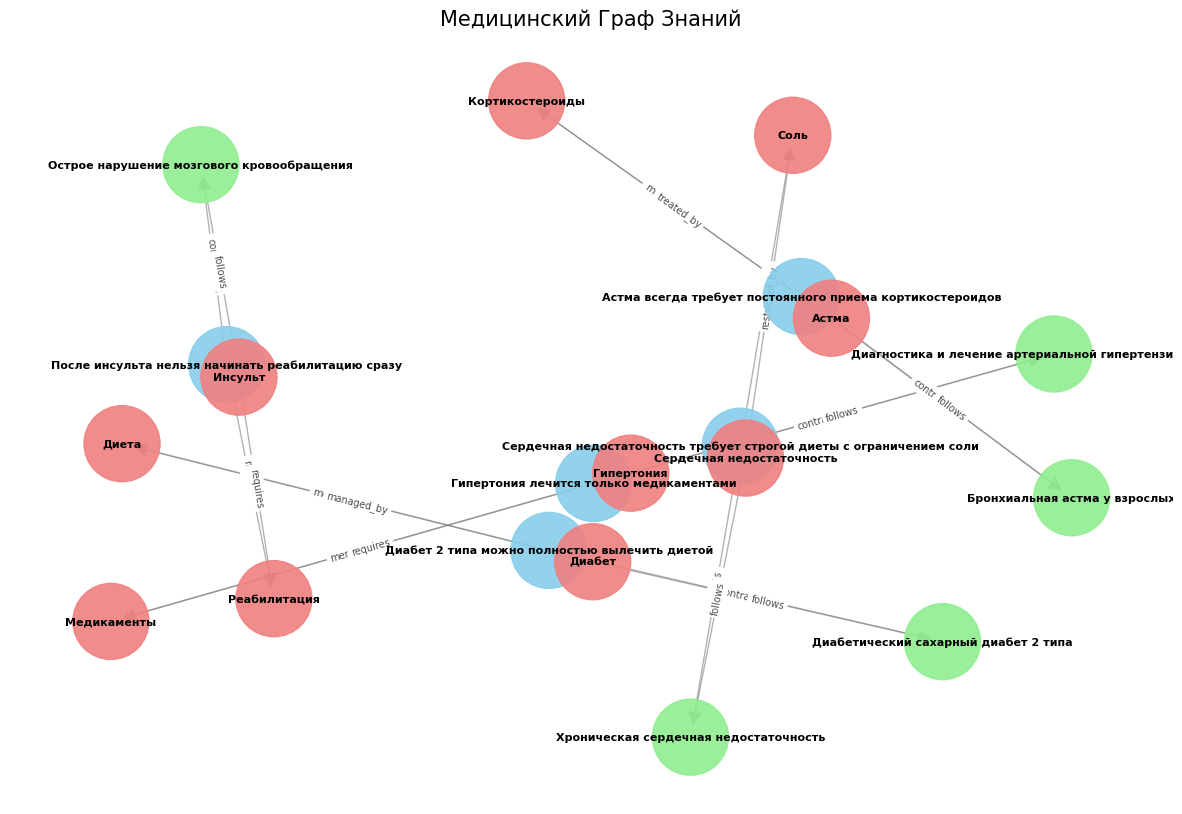

In [18]:
G = nx.DiGraph()

# Добавляем узлы
for node_id, node_data in MEDICAL_KNOWLEDGE_GRAPH["nodes"].items():
    label = node_data.get("name", node_data.get("content", node_id))
    G.add_node(node_id, label=label, type=node_data["type"], category=node_data.get("category", ""), verdict=node_data.get("verdict", ""))

# Добавляем рёбра
for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
    G.add_edge(edge["source"], edge["target"], relation=edge["relation"], weight=edge["weight"])

# Подготовка для визуализации
plt.figure(figsize=(15, 10))
pos = nx.spring_layout(G, k=0.3, iterations=50) # Увеличиваем расстояние между узлами

# Цвета для разных типов узлов
node_colors = []
for node_id in G.nodes():
    if G.nodes[node_id]["type"] == "claim":
        node_colors.append("skyblue")
    elif G.nodes[node_id]["type"] == "guideline":
        node_colors.append("lightgreen")
    elif G.nodes[node_id]["type"] == "entity":
        node_colors.append("lightcoral")
    else:
        node_colors.append("lightgray")

# Отрисовка узлов
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000, alpha=0.9)

# Отрисовка рёбер
nx.draw_networkx_edges(G, pos, edge_color="gray", arrowsize=20, alpha=0.6)

# Метки узлов
node_labels = {node_id: G.nodes[node_id]["label"] for node_id in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8, font_weight="bold")

# Метки рёбер (отношения)
edge_labels = nx.get_edge_attributes(G, "relation")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, alpha=0.7)

plt.title("Медицинский Граф Знаний", size=15)
plt.axis("off")
plt.show()

In [19]:
import json
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict, Any
from langchain_mistralai import ChatMistralAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_classic.agents import AgentExecutor, create_tool_calling_agent
import re


# --- ИНСТРУМЕНТЫ ---

@tool
def search_clinical_guidelines_ru(condition: str, language: str = "ru") -> str:
    """
    Поиск российских клинических рекомендаций по заболеванию/состоянию.
    """
    condition_lower = condition.lower()
    matching_guidelines = []
    for key, data in CLINICAL_REQUIREMENTS_DB.items():
        if condition_lower in key.lower() or condition_lower in data["ru"].lower() or condition_lower in data["en"].lower():
            matching_guidelines.append(data)

    if not matching_guidelines:
        return json.dumps({
            "summary": f"Не найдено клинических рекомендаций для '{condition}'.",
            "evidence_base": [],
            "language": language
        })

    # Возвращаем все найденные рекомендации
    results = []
    for guideline in matching_guidelines:
        if language.lower() == "ru":
            content = {
                "condition": guideline["ru"],
                "guidelines": guideline["guidelines"],
                "url": guideline["url"],
                "last_updated": guideline["last_updated"],
                "evidence_level": guideline["evidence_level"],
                "language": "ru"
            }
        else:
            content = {
                "condition": guideline["en"],
                "guidelines": guideline["guidelines"],
                "url": guideline["url"],
                "last_updated": guideline["last_updated"],
                "evidence_level": guideline["evidence_level"],
                "language": "en"
            }
        results.append(content)

    return json.dumps({
        "summary": f"Найдено {len(results)} рекомендаций для '{condition}'.",
        "evidence_base": results,
        "language": language
    }, ensure_ascii=False)


@tool
def query_clinical_knowledge_graph_ru(condition_or_issue: str, language: str = "ru") -> str:
    """
    Запрос к графу знаний для получения связанных сущностей и отношений по проблеме пациента.
    """
    # Ищем узлы, соответствующие проблеме (сущности, утверждения)
    related_nodes = {}
    for node_id, node_data in MEDICAL_KNOWLEDGE_GRAPH["nodes"].items():
        content_to_check = node_data.get("content", "") or node_data.get("name", "")
        if condition_or_issue.lower() in content_to_check.lower():
            related_nodes[node_id] = node_data

    # Если не нашли напрямую, ищем связанные узлы через рёбра
    if not related_nodes:
        for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
            source_node = MEDICAL_KNOWLEDGE_GRAPH["nodes"][edge["source"]]
            target_node = MEDICAL_KNOWLEDGE_GRAPH["nodes"][edge["target"]]
            source_content = source_node.get("content", "") or source_node.get("name", "")
            target_content = target_node.get("content", "") or target_node.get("name", "")

            if condition_or_issue.lower() in source_content.lower() or condition_or_issue.lower() in target_content.lower():
                related_nodes[edge["source"]] = MEDICAL_KNOWLEDGE_GRAPH["nodes"][edge["source"]]
                related_nodes[edge["target"]] = MEDICAL_KNOWLEDGE_GRAPH["nodes"][edge["target"]]

    if not related_nodes:
        return json.dumps({
            "issue": condition_or_issue,
            "summary": f"Не найдены узлы графа, связанные с '{condition_or_issue}'.",
            "related_entities": [],
            "relationships": [],
            "language": language
        })

    # Находим рёбра между найденными узлами
    related_edges = []
    node_ids = set(related_nodes.keys())
    for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
        if edge["source"] in node_ids and edge["target"] in node_ids:
            related_edges.append(edge)

    node_details = []
    for node_id, node_data in related_nodes.items():
         node_details.append({
             "id": node_id,
             "type": node_data["type"],
             "name_or_content": node_data.get("name", node_data.get("content", "")),
             "category": node_data.get("category", ""),
             "verdict": node_data.get("verdict", ""), # Только для утверждений
             "language": node_data.get("language", "ru"),
         })

    return json.dumps({
        "issue": condition_or_issue,
        "summary": f"Найдено {len(related_nodes)} связанных узлов и {len(related_edges)} связей в графе знаний.",
        "related_entities": node_details,
        "relationships": related_edges,
        "language": language
    }, ensure_ascii=False)


@tool
def generate_operator_tips_from_graph(issue: str, graph_results_str: str, language: str = "ru") -> str:
    """
    Генерирует советы оператору на основе анализа результатов запроса к графу.
    """
    try:
        graph_results = json.loads(graph_results_str)
    except json.JSONDecodeError:
        print(f"DEBUG: Failed to parse graph_results_str: {graph_results_str}")
        return json.dumps({"error": "Невозможно разобрать результаты запроса к графу.", "tips": []}, ensure_ascii=False)

    tips = []
    # Примеры правил на основе графа
    for entity_info in graph_results.get("related_entities", []):
        entity_name = entity_info.get("name_or_content", "")
        entity_type = entity_info.get("type", "")
        entity_category = entity_info.get("category", "")
        verdict = entity_info.get("verdict", "")

        if entity_type == "claim":
            if verdict == "refuted":
                tips.append(f"Важно: Утверждение, связанное с '{entity_name}', опровергнуто. Не рекомендуйте это пациенту.")
            elif verdict == "supported":
                 tips.append(f"Подтверждено: Информация о '{entity_name}' подтверждена клиническими данными.")

        if entity_category == "treatment" or entity_category == "medication":
             tips.append(f"Возможное лечение/лекарство: '{entity_name}'. Проверьте рекомендации.")

        if entity_category == "disease":
            if entity_name.lower() != issue.lower(): # Не повторять исходное заболевание
                tips.append(f"Сопутствующее заболевание/состояние: '{entity_name}'. Уточните у пациента.")


    # Проверяем связи
    for rel in graph_results.get("relationships", []):
        if rel.get("relation") == "requires" or rel.get("relation") == "treated_by":
            source_name = next((n["name_or_content"] for n in graph_results.get("related_entities", []) if n["id"] == rel["source"]), "")
            target_name = next((n["name_or_content"] for n in graph_results.get("related_entities", []) if n["id"] == rel["target"]), "")
            if source_name and target_name:
                 tips.append(f"Связь '{rel['relation']}': '{source_name}' связано с '{target_name}'. Уточните детали.")


    # Добавляем обобщённые советы на основе типов найденных узлов
    entity_types_found = set(e.get("type", "") for e in graph_results.get("related_entities", []))
    if "guideline" in entity_types_found:
        tips.append("Найдены ссылки на клинические рекомендации. Передайте пациенту или врачу.")

    return json.dumps({
        "issue": issue,
        "tips_for_operator": tips,
        "language": language
    }, ensure_ascii=False)

# Agent

In [21]:


# --- АГЕНТ ТЕЛЕМЕДИЦИНСКОГО АНАЛИЗА ---

class TelemedicineAnalysisAgent:
    """
    Агент для анализа медицинской проблемы пациента.
    """
    def __init__(self, llm_interface, tools):
        self.llm_interface = llm_interface
        self.tools = tools

        # Создаём промпт для агента
        prompt = ChatPromptTemplate.from_messages([
            ("system", """
            Вы помощник телемедицинской консультации.
            Ваша задача - получить медицинскую проблему пациента (на русском языке) и предоставить:
            1. Краткое резюме проблемы.
            2. Доказательную базу: ссылки на релевантные российские клинические рекомендации.
            3. Советы оператору на основе анализа медицинского графа знаний.

            Используйте следующие инструменты:
            - search_clinical_guidelines_ru: Поиск клинических рекомендаций по заболеванию.
            - query_clinical_knowledge_graph_ru: Запрос графа знаний для получения связанных сущностей и отношений.
            - generate_operator_tips_from_graph: Генерация советов оператору на основе **прямых JSON-результатов** запроса к графу. Аргумент `graph_results_str` должен быть **полной JSON-строкой**, полученной от `query_clinical_knowledge_graph_ru`.

            Форматируйте ответ на русском языке четко и структурировано.
            """),
            ("user", "{input}"),
            MessagesPlaceholder(variable_name="agent_scratchpad"),
        ])

        # Создаём агента
        agent = create_tool_calling_agent(llm_interface, tools, prompt)
        self.agent_executor = AgentExecutor(
            agent=agent,
            tools=tools,
            verbose=True, # Для отладки
            handle_parsing_errors=True
        )

    def analyze_issue(self, issue_description: str) -> Dict[str, Any]:
        """
        Анализирует проблему пациента.
        """
        input_text = f"Проанализируйте следующую медицинскую проблему пациента: '{issue_description}'. Предоставьте краткое резюме, доказательную базу и советы оператору."
        result = self.agent_executor.invoke({"input": input_text})
        return result

# Code run

In [23]:
def main():
    print("🏥 Анализ медицинской проблемы пациента для телемедицины")
    print("=" * 70)

    # Инициализация агента
    tools = [search_clinical_guidelines_ru, query_clinical_knowledge_graph_ru, generate_operator_tips_from_graph]
    agent = TelemedicineAnalysisAgent(llm, tools) # Передаём mock llm

    # Пример проблемы пациента (на русском)
    patient_issue = "Пациент жалуется на высокое давление и головные боли. Подозревает гипертонию."

    print(f"\n📋 Входная проблема: {patient_issue}\n")
    print("-" * 50)

    # Запуск анализа
    analysis_result = agent.analyze_issue(patient_issue)

    print("\n📊 Результаты анализа:")
    print(analysis_result.get("output", "Нет результата")) # Выводим сгенерированный текст агента


if __name__ == "__main__":
    main()

🏥 Анализ медицинской проблемы пациента для телемедицины

📋 Входная проблема: Пациент жалуется на высокое давление и головные боли. Подозревает гипертонию.

--------------------------------------------------


> Entering new AgentExecutor chain...

Invoking: `search_clinical_guidelines_ru` with `{'condition': 'артериальная гипертензия'}`
responded: Хорошо, я начну анализ медицинской проблемы пациента.

**Шаг 1:** Краткое резюме проблемы.
Пациент сообщает о наличии высокого давления и головных болей. Он подозревает у себя гипертонию. Это может указывать на возможное наличие артериальной гипертензии, но требует дальнейшей диагностики и подтверждения.

**Шаг 2:** Поиск клинических рекомендаций.
Я выполню поиск клинических рекомендаций по запросу "гипертония" или "артериальная гипертензия".

{"summary": "\u041d\u0435 \u043d\u0430\u0439\u0434\u0435\u043d\u043e \u043a\u043b\u0438\u043d\u0438\u0447\u0435\u0441\u043a\u0438\u0445 \u0440\u0435\u043a\u043e\u043c\u0435\u043d\u0434\u0430\u0446\u0438